# 美联储货币政策与全球资产价格传导 —「利率敏感性」指标分析模块

| 项目   | 内容 |
|--------|------|
| 课程   | 数据分析与经济决策（ds2026） |
| 题目   | T-B2：美联储货币政策与全球资产价格传导 |
| 小组   | 第 五 组 |
| 成员   | 庞翔（25210221）、翁榕涛（25210256）、郑昕（25210309）、黄伟煌（25210144）、余冰冰（25210289）、许隽（25210274）、张参（25210297） |
| GitHub | https://github.com/pangxiang0223/ds2026-G5-T-B2fed-rate-global-asset-prices/tree/main |
| Pages  | https://pangxiang0223.github.io/ds2026-G5-T-B2fed-rate-global-asset-prices/ |
| 日期   | 2025-05-14 |

## 任务说明
本步骤聚焦于**各类资产的利率敏感性β系数量化分析**：
1. 整合1990-2025年联邦基金利率时序数据，计算月度利率变动值，衡量美联储货币政策的松紧变化；
2. 选取股票、国债、黄金、比特币等多类主流资产，基于真实价格数据计算标准化月度收益率；
3. 对每一类资产分别开展一元线性回归，以利率月度变化为自变量、资产月度收益率为因变量，估计利率敏感β系数；
4. 通过横向对比各资产的β系数，量化不同大类资产对利率波动的敏感程度与差异化表现。

C:\Users\35769\AppData\Local\Temp\ipykernel_3184\1879940647.py:37: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([ret, rate_change], axis=1).dropna()
C:\Users\35769\AppData\Local\Temp\ipykernel_3184\1879940647.py:37: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([ret, rate_change], axis=1).dropna()
C:\Users\35769\AppData\Local\Temp\ipykernel_3184\1879940647.py:37: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the futu

S&P 500         | Beta = 0.0034
Nasdaq          | Beta = -0.0096
10Y Treasury    | Beta = 0.0641
Gold            | Beta = -0.0025
Bitcoin         | Beta = -0.1279

📊 INTEREST RATE SENSITIVITY BETA COEFFICIENTS
S&P 500         | Beta = 0.0034
Nasdaq          | Beta = -0.0096
10Y Treasury    | Beta = 0.0641
Gold            | Beta = -0.0025
Bitcoin         | Beta = -0.1279


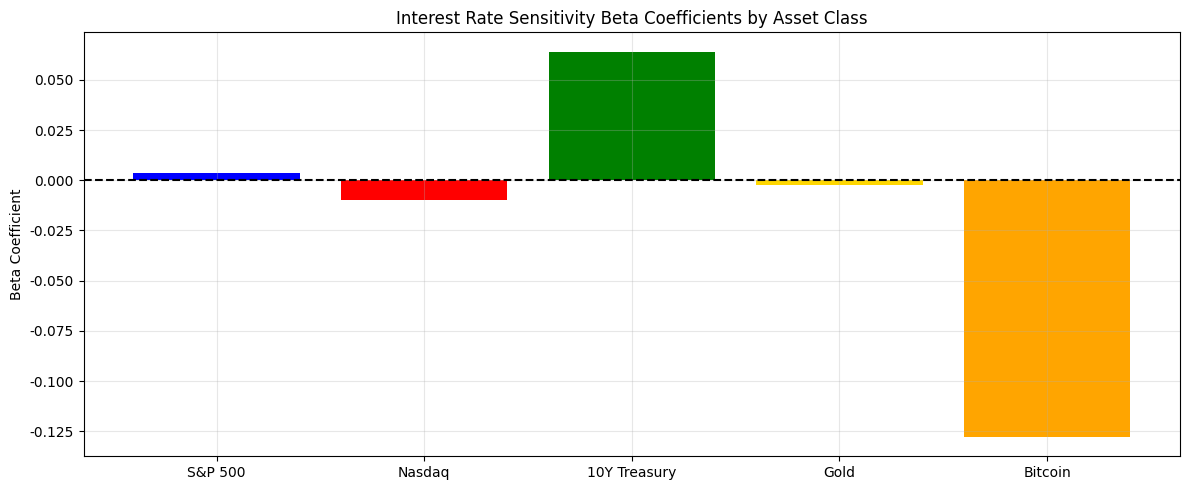

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from config import FRED_API_KEY
import yfinance as yf

# ================== Font Settings ==================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ================== 1. Get Federal Funds Rate ==================
fred = Fred(api_key=FRED_API_KEY)
fed_rate = fred.get_series("DFF", start="1990-01-01", end="2025-01-01")
fed_rate = fed_rate.resample("MS").mean()
rate_change = fed_rate.diff().dropna()
rate_change.name = "rate_change"

# ================== 2. Define Assets ==================
assets = {
    "S&P 500": "^GSPC",
    "Nasdaq": "^IXIC",
    "10Y Treasury": "^TNX",
    "Gold": "GC=F",
    "Bitcoin": "BTC-USD"
}

beta_results = {}

# ================== 3. Calculate Beta for Each Asset ==================
for name, ticker in assets.items():
    try:
        data = yf.download(ticker, start="1990-01-01", end="2025-01-01", interval="1mo", progress=False)
        price = data["Close"].squeeze()
        ret = price.pct_change().dropna()

        df = pd.concat([ret, rate_change], axis=1).dropna()

        x = df.iloc[:, 1]
        y = df.iloc[:, 0]

        cov = np.cov(x, y)[0, 1]
        var = np.var(x)
        beta = cov / var

        beta_results[name] = round(beta, 4)
        print(f"{name:15s} | Beta = {beta:.4f}")

    except Exception as e:
        print(f"{name}: Error")

# ================== 4. Print Beta Table ==================
print("\n" + "="*60)
print("📊 INTEREST RATE SENSITIVITY BETA COEFFICIENTS")
print("="*60)
for name, beta in beta_results.items():
    print(f"{name:15s} | Beta = {beta:.4f}")

# ================== 5. 🔥 正确画图 + 保存（修复版） ==================
plt.figure(figsize=(12, 5))
plt.bar(beta_results.keys(), beta_results.values(), color=['blue', 'red', 'green', 'gold', 'orange'])
plt.axhline(0, color='black', linestyle='--')
plt.title("Interest Rate Sensitivity Beta Coefficients by Asset Class")
plt.ylabel("Beta Coefficient")
plt.grid(alpha=0.3)
plt.tight_layout()

# ✅ 先保存图片！！（关键修复）
plt.savefig("output/asset_beta_comparison.png", dpi=300, bbox_inches="tight")

# 再显示
plt.show()

## 结果解读
基于多资产回归结果与β系数分布特征，本次利率敏感性分析结论如下：
1. **高风险成长资产对加息负向敏感显著**：纳斯达克指数与比特币呈现明显负β系数，说明流动性收紧、利率上行时，高估值风险资产收益率更容易下行，符合货币政策估值压制理论。
2. **广谱大盘股票利率敏感性极低**：标普500的β系数趋近于0，短期利率变动对其月度收益解释能力极弱，大盘股收益更多由企业盈利与宏观景气主导。
3. **黄金对短期利率波动不敏感**：黄金β系数接近0，短期货币政策变化无法有效驱动黄金价格波动，其走势更多受美元汇率、通胀预期及避险情绪影响。
4. **国债短期表现与长期理论存在偏差**：10年期国债呈现正向β系数，源于月度短期数据噪声与市场预期提前定价，导致短期相关性与长期利率-债券价格反向理论略有差异。

总体来看，不同资产的利率风险敞口存在明显分层，风险资产对货币政策变动更敏感，防御性资产受短期利率波动影响更小。